## fluxo de Hyperparameter Optimization com Spark ML

In [0]:
import mlflow
import mlflow.spark
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.sql import SparkSession

# 1. Inicializar a sessão PySpark (caso esteja rodando fora do Databricks)
spark = SparkSession.builder.appName("SparkML_HyperparameterTuning").getOrCreate()

# 2. Criar dados sintéticos para execução do exemplo
data = [
    (1.5, 2.3, 10.5),
    (3.0, 4.1, 20.1),
    (4.5, 1.2, 14.8),
    (5.0, 5.5, 30.2),
    (2.1, 3.8, 17.4),
    (6.2, 2.9, 25.0),
    (7.1, 6.0, 42.1),
    (1.8, 0.9, 8.3),
    (8.0, 7.2, 50.0),
    (3.5, 5.0, 24.1),
]

columns = ["feature_1", "feature_2", "label"]
df = spark.createDataFrame(data, schema=columns)



{"ts": "2026-09-14 01:12:20.755", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjA3NzgyMTc4MTMxMDMwNBABIAEyJDAxYTA5ZDc4LTg4NzUtN2M4Ny1iNmU5LTU2OTgzOTQ0ZjE3NDokYjRkNGM2MjYtNmUxMi0zYzI2LTg1ZTMtODVhMDM3NmE2OTkxSgwI3ZOd1QYQwMrDjwFQAVgBYAFo+ojAupbFow0=.", "context": {}}
{"ts": "2026-09-14 01:12:20.755", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjA3NzgyMTc4MTMxMDMwNBABIAEyJDAxYTA5ZDc4LTg4NzUtN2M4Ny1iNmU5LTU2OTgzOTQ0ZjE3NDokYjRkNGM2MjYtNmUxMi0zYzI2LTg1ZTMtODVhMDM3NmE2OTkxSgwI3ZOd1QYQwMrDjwFQAVgBYAFo+ojAupbFow0=.", "context": {}}
{"ts": "2026-09-14 01:12:20.755", "level": "WARNING", "logger": "pyspark.sql.connect.logging", "msg": "Effective usage policy for this session is cct.Chpub3RlYm9va3MvMjA3NzgyMTc4MTMxMDMwNBABIAEyJDAxYTA5ZDc4LTg4NzUtN2M4Ny1iNmU5LTU2OTgzOTQ0ZjE3NDokYjRkNGM2MjYtNmUxMi0zYzI2LTg1ZTMtODVhMDM3NmE2OTkx

In [0]:
display(df.show(4))

+---------+---------+-----+
|feature_1|feature_2|label|
+---------+---------+-----+
|      1.5|      2.3| 10.5|
|      3.0|      4.1| 20.1|
|      4.5|      1.2| 14.8|
|      5.0|      5.5| 30.2|
+---------+---------+-----+
only showing top 4 rows


In [0]:
import os
os.environ["SPARKML_TEMP_DFS_PATH"] = "/Volumes/workspace/default/mlflow_tmp"
os.environ["MLFLOW_DFS_TMP"] = "/Volumes/workspace/default/mlflow_tmp"

# Preparar o vetor de features exigido pelo Spark ML
assembler = VectorAssembler(
    inputCols=["feature_1", "feature_2"], outputCol="features"
)
trainingData = assembler.transform(df)

# ==============================================================================
# FLUXO DA IMAGEM: HYPERPARAMETER OPTIMIZATION WITH SPARK ML
# ==============================================================================

# Definição do Modelo, Grade de Hiperparâmetros e Avaliador
dt = DecisionTreeRegressor(featuresCol="features", labelCol="label")

paramGrid = (
    ParamGridBuilder()
    .addGrid(dt.maxDepth, [3, 5, 10])
    .addGrid(dt.minInstancesPerNode, [1, 2, 4])
    .build()
)

evaluator = RegressionEvaluator(
    labelCol="label", predictionCol="prediction", metricName="rmse"
)

# Cross-Validation e Treinamento do Modelo
cv = CrossValidator(
    estimator=dt,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
)

# Iniciar o Rastreamento com MLflow
mlflow.set_experiment("/SparkML_DecisionTree_Tuning")

with mlflow.start_run(run_name="DecisionTree_CrossValidation") as run:
    # Ajustar a validação cruzada no conjunto de treino
    cvModel = cv.fit(trainingData)

    # Obter o melhor modelo da busca
    best_model = cvModel.bestModel

    # Log das métricas do melhor modelo
    predictions = cvModel.transform(trainingData)
    rmse = evaluator.evaluate(predictions)
    mlflow.log_metric("rmse", rmse)

    # Log dos hiperparâmetros do melhor modelo
    mlflow.log_param("best_maxDepth", best_model.getMaxDepth())
    mlflow.log_param(
        "best_minInstancesPerNode", best_model.getMinInstancesPerNode()
    )

    # Registrar/Salvar o melhor modelo PySpark ML no MLflow
    mlflow.spark.log_model(cvModel.bestModel, "best_sparkml_model")

    print(f"✅ Treinamento concluído com sucesso!")
    print(f"📊 Menor RMSE: {rmse:.4f}")
    print(
        f"🌲 Melhores Parâmetros: maxDepth={best_model.getMaxDepth()}, minInstancesPerNode={best_model.getMinInstancesPerNode()}"
    )

2026/09/14 01:21:34 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/09/14 01:21:39 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-80f921ae-1fdb-403c-a2d7-f4/tmpgt8w14zh/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/09/14 01:21:39 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Treinamento concluído com sucesso!
📊 Menor RMSE: 0.0000
🌲 Melhores Parâmetros: maxDepth=5, minInstancesPerNode=1


In [0]:
# Gerar inferência nos dados usando o melhor modelo selecionado
predictions_df = cvModel.transform(trainingData)
predictions_df.select("features", "label", "prediction").show(5)

+---------+-----+------------------+
| features|label|        prediction|
+---------+-----+------------------+
|[1.5,2.3]| 10.5|              10.5|
|[3.0,4.1]| 20.1|              20.1|
|[4.5,1.2]| 14.8|              14.8|
|[5.0,5.5]| 30.2|30.199999999999996|
|[2.1,3.8]| 17.4|              17.4|
+---------+-----+------------------+
only showing top 5 rows


In [0]:
predictions_df.count()

10

In [0]:
display(predictions_df.show(10))

+---------+---------+-----+---------+------------------+
|feature_1|feature_2|label| features|        prediction|
+---------+---------+-----+---------+------------------+
|      1.5|      2.3| 10.5|[1.5,2.3]|              10.5|
|      3.0|      4.1| 20.1|[3.0,4.1]|              20.1|
|      4.5|      1.2| 14.8|[4.5,1.2]|              14.8|
|      5.0|      5.5| 30.2|[5.0,5.5]|30.199999999999996|
|      2.1|      3.8| 17.4|[2.1,3.8]|              17.4|
|      6.2|      2.9| 25.0|[6.2,2.9]|              25.0|
|      7.1|      6.0| 42.1|[7.1,6.0]|              42.1|
|      1.8|      0.9|  8.3|[1.8,0.9]|               8.3|
|      8.0|      7.2| 50.0|[8.0,7.2]| 49.99999999999999|
|      3.5|      5.0| 24.1|[3.5,5.0]|              24.1|
+---------+---------+-----+---------+------------------+



# Optuna

### Otimização de Hiperparâmetros Single-Node com Optuna, TPESampler e MLflow:

In [0]:
%pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.9/611.9 kB 29.1 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import mlflow
import mlflow.sklearn
import optuna
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split

In [0]:

# 1. Preparar dados sintéticos para o exemplo
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)

In [0]:
X

array([[ 0.96479937, -0.06644898,  0.98676805, ..., -1.2101605 ,
        -0.62807677,  1.22727382],
       [-0.91651053, -0.56639459, -1.00861409, ..., -0.98453405,
         0.36389642,  0.20947008],
       [-0.10948373, -0.43277388, -0.4576493 , ..., -0.2463834 ,
        -1.05814521, -0.29737608],
       ...,
       [ 1.67463306,  1.75493307,  1.58615382, ...,  0.69272276,
        -1.50384972,  0.22526412],
       [-0.77860873, -0.83568901, -0.19484228, ..., -0.49735437,
         2.47213818,  0.86718741],
       [ 0.24845351, -1.0034389 ,  0.36046013, ...,  0.77323999,
         0.1857344 ,  1.41641179]])

In [0]:
y

array([0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,

In [0]:


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Configurar o experimento no MLflow
mlflow.set_experiment("/Optuna_Hyperparameter_Optimization")

# ==============================================================================
# FLUXO DA IMAGEM: OPTUNA SINGLE-NODE OPTIMIZATION
# ==============================================================================


# Define objective function
def objective(trial):
    # Write your machine learning logic here!
    # Pythonic search spaces
    max_depth = trial.suggest_int("max_depth", 2, 20)
    n_estimators = trial.suggest_int("n_estimators", 10, 150)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    clf = RandomForestClassifier(
        max_depth=max_depth,
        n_estimators=n_estimators,
        min_samples_split=min_samples_split,
        random_state=42,
    )

    # Avaliação por Validação Cruzada (Acurácia)
    score = cross_val_score(clf, X_train, y_train, cv=3, scoring="accuracy").mean()
    return score


# Iniciar a execução do MLflow
with mlflow.start_run(run_name="Optuna_TPESampler_Run"):

    # Run optimization with parallelization
    study = optuna.create_study(
        sampler=optuna.samplers.TPESampler(), direction="maximize"
    )
    study.optimize(objective, n_trials=50, n_jobs=-1)

    # Registrar parâmetros e métricas no MLflow
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_value", study.best_value)

    # Treinar e registrar o melhor modelo final
    best_clf = RandomForestClassifier(**study.best_params, random_state=42)
    best_clf.fit(X_train, y_train)

    test_accuracy = accuracy_score(y_test, best_clf.predict(X_test))
    mlflow.log_metric("test_accuracy", test_accuracy)
    mlflow.sklearn.log_model(best_clf, "best_optuna_model")

    print(f"✅ Otimização Concluída!")
    print(f"📊 Melhor Acurácia no Treino (CV): {study.best_value:.4f}")
    print(f"🎯 Acurácia no Teste: {test_accuracy:.4f}")
    print(f"⚙️ Melhores Parâmetros: {study.best_params}")

# Quick visualization (No Databricks/Jupyter)
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

2026/09/14 01:29:45 INFO mlflow.tracking.fluent: Experiment with name '/Optuna_Hyperparameter_Optimization' does not exist. Creating a new experiment.
[I 2026-09-14 01:29:46,259] A new study created in memory with name: no-name-1c6fc06e-64d9-4744-a278-356b51d0809f
[I 2026-09-14 01:29:47,611] Trial 2 finished with value: 0.8987215229083946 and parameters: {'max_depth': 6, 'n_estimators': 55, 'min_samples_split': 5}. Best is trial 2 with value: 0.8987215229083946.
[I 2026-09-14 01:29:48,920] Trial 3 finished with value: 0.8987215229083946 and parameters: {'max_depth': 15, 'n_estimators': 111, 'min_samples_split': 8}. Best is trial 2 with value: 0.8987215229083946.
[I 2026-09-14 01:29:48,969] Trial 1 finished with value: 0.9049637201618278 and parameters: {'max_depth': 20, 'n_estimators': 113, 'min_samples_split': 4}. Best is trial 1 with value: 0.9049637201618278.
[I 2026-09-14 01:29:49,219] Trial 0 finished with value: 0.8999699623590812 and parameters: {'max_depth': 9, 'n_estimators': 

✅ Otimização Concluída!
📊 Melhor Acurácia no Treino (CV): 0.9100
🎯 Acurácia no Teste: 0.8850
⚙️ Melhores Parâmetros: {'max_depth': 12, 'n_estimators': 53, 'min_samples_split': 2}


In [0]:
#%pip install optuna mlflow scikit-learn plotly

## Multi-Metric Optimization (Otimização Multiobjetivo / Pareto Front)

Utilizado quando você quer otimizar múltiplas métricas simultaneamente (por exemplo: maximizar Acurácia e F1-Score ao mesmo tempo).

In [0]:
import mlflow
import optuna
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

# 1. Preparar dados
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=10, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [0]:
X,y

(array([[ 0.48417939,  1.11214906, -3.70085989, ..., -1.00853081,
         -7.1748857 , -4.35765421],
        [ 0.1932462 , -0.31460145, -2.16041377, ...,  0.57110263,
          3.00423929,  2.15871481],
        [-0.93037466,  0.87930729, -0.60058682, ..., -0.28279321,
         -0.92962181, -3.07008362],
        ...,
        [ 0.96274777, -0.16340723, -1.96894712, ...,  1.22234526,
         -3.24699501, -0.22840546],
        [ 2.03009074,  1.29375316,  0.44320221, ..., -0.79782212,
          0.75653214,  1.99347097],
        [ 0.74831818,  0.04138576, -4.42924471, ...,  1.6984587 ,
         -0.36104445,  0.69751592]]),
 array([1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
        0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0,
        1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1,
        1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
   

In [0]:


# 2. Definição da função objetivo multiobjetivo
def objective_multi_metric(trial):
    # Espaço de busca de hiperparâmetros
    n_estimators = trial.suggest_int("n_estimators", 10, 100)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    # Treinamento do modelo
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
    )
    model.fit(X_train, y_train)

    # Predições
    preds = model.predict(X_val)

    # Avaliação das duas métricas
    accuracy = accuracy_score(y_val, preds)
    f1 = f1_score(y_val, preds, average="macro")

    # Retorna ambas as métricas
    return accuracy, f1


# 3. Criar e otimizar o estudo para maximizar ambas as métricas
study_multi_metric = optuna.create_study(
    directions=["maximize", "maximize"]  # Múltiplos objetivos
)
study_multi_metric.optimize(objective_multi_metric, n_trials=30, n_jobs=-1)

# 4. Exibir resultados dos melhores trials na fronteira de Pareto
print("=== Melhores Trials (Pareto Front) ===")
for trial in study_multi_metric.best_trials:
    print(f"Trial #{trial.number}")
    print(f"  Métricas (Accuracy, F1-Score): {trial.values}")
    print(f"  Parâmetros: {trial.params}")

# Visualização da Fronteira de Pareto
fig = optuna.visualization.plot_pareto_front(
    study_multi_metric, target_names=["Accuracy", "F1-Score"]
)
fig.show()

[I 2026-09-14 01:36:35,437] A new study created in memory with name: no-name-4d5ff246-3f81-4733-8209-2c1c2319aa24
[I 2026-09-14 01:36:35,789] Trial 0 finished with values: [0.935, 0.934998374959374] and parameters: {'n_estimators': 38, 'max_depth': 13, 'min_samples_split': 2}.
[I 2026-09-14 01:36:35,847] Trial 2 finished with values: [0.9, 0.8999899989999001] and parameters: {'n_estimators': 49, 'max_depth': 17, 'min_samples_split': 7}.
[I 2026-09-14 01:36:36,009] Trial 5 finished with values: [0.885, 0.8849741191768148] and parameters: {'n_estimators': 18, 'max_depth': 10, 'min_samples_split': 9}.
[I 2026-09-14 01:36:36,020] Trial 3 finished with values: [0.91, 0.91] and parameters: {'n_estimators': 68, 'max_depth': 16, 'min_samples_split': 9}.
[I 2026-09-14 01:36:36,045] Trial 1 finished with values: [0.905, 0.9049976249406235] and parameters: {'n_estimators': 78, 'max_depth': 8, 'min_samples_split': 2}.
[I 2026-09-14 01:36:36,285] Trial 6 finished with values: [0.835, 0.834962866644

=== Melhores Trials (Pareto Front) ===
Trial #28
  Métricas (Accuracy, F1-Score): [0.94, 0.9399759903961584]
  Parâmetros: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 4}


In [0]:
fig.write_html("pareto_ml1.html")

# Multi-Model Optimization (Seleção Dinâmica de Algoritmos)

Utilizado quando você quer testar diferentes algoritmos (ex: SVC vs RandomForest) na mesma busca, ajustando os hiperparâmetros específicos de cada um.

In [0]:
import mlflow
import optuna
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# 1. Preparar dados
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2. Definição da função objetivo multi-modelo
def objective_multi_model(trial):
    # Escolha dinâmica do classificador
    classifier = trial.suggest_categorical(
        "classifier", ["SVC", "RandomForest"]
    )

    if classifier == "SVC":
        # Espaço de busca para SVC
        c = trial.suggest_float("svc_c", 1e-3, 1e2, log=True)
        kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])
        model = SVC(C=c, kernel=kernel, random_state=42)

    else:
        # Espaço de busca para RandomForest
        max_depth = trial.suggest_int("rf_max_depth", 2, 20)
        n_estimators = trial.suggest_int("rf_n_estimators", 10, 100)
        model = RandomForestClassifier(
            max_depth=max_depth, n_estimators=n_estimators, random_state=42
        )

    # Treinamento e avaliação
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    evaluation_score = accuracy_score(y_val, preds)

    return evaluation_score


# 3. Criar e otimizar estudo de único objetivo (Acurácia)
study_multi_model = optuna.create_study(direction="maximize")
study_multi_model.optimize(objective_multi_model, n_trials=30, n_jobs=-1)

# 4. Imprimir o melhor resultado conforme exibido na imagem
best_trial = study_multi_model.best_trial
print(f"Best trial metrics: {best_trial.values}")
print(f"Best params: {list(best_trial.params.items())}")

# Visualização do histórico de otimização
fig = optuna.visualization.plot_optimization_history(study_multi_model)
fig.show()

[I 2026-09-14 01:59:31,619] A new study created in memory with name: no-name-beb0bc27-1df0-4654-a17e-5d46628e8a8b
[I 2026-09-14 01:59:31,655] Trial 0 finished with value: 0.865 and parameters: {'classifier': 'SVC', 'svc_c': 0.007122987267472097, 'kernel': 'linear'}. Best is trial 0 with value: 0.865.
[I 2026-09-14 01:59:31,656] Trial 3 finished with value: 0.875 and parameters: {'classifier': 'SVC', 'svc_c': 0.02115708986033032, 'kernel': 'linear'}. Best is trial 3 with value: 0.875.
[I 2026-09-14 01:59:31,679] Trial 1 finished with value: 0.87 and parameters: {'classifier': 'SVC', 'svc_c': 3.9695826018431997, 'kernel': 'linear'}. Best is trial 3 with value: 0.875.
[I 2026-09-14 01:59:31,695] Trial 4 finished with value: 0.85 and parameters: {'classifier': 'SVC', 'svc_c': 9.345914896567066, 'kernel': 'rbf'}. Best is trial 3 with value: 0.875.
[I 2026-09-14 01:59:31,866] Trial 6 finished with value: 0.87 and parameters: {'classifier': 'SVC', 'svc_c': 4.75433939759147, 'kernel': 'linear'

Best trial metrics: [0.905]
Best params: [('classifier', 'RandomForest'), ('rf_max_depth', 13), ('rf_n_estimators', 56)]


In [0]:
fig.write_html("pareto_ml2.html")

três conceitos de Advanced Options in Optuna exibidos no slide da aula:

Acessar histórico do estudo (study.best_params, study.trials, study.best_value, etc.).

Retomar a otimização chamando study.optimize(...) novamente.

Passar parâmetros adicionais na função objetivo usando lambda / wrapper.

In [0]:
import numpy as np
import optuna
import pandas as pd
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

# ==============================================================================
# 1. OBJETIVO COM MÚLTIPLOS PARÂMETROS (Passando X, y, cv, scoring com Lambda)
# ==============================================================================


# Definição da função objetivo recebendo parâmetros adicionais
def objective(trial, X, y, cv, scoring):
    # Machine Learning Logic
    n_estimators = trial.suggest_int("n_estimators", 10, 100)
    max_depth = trial.suggest_int("max_depth", 2, 20)
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
    )

    # Avaliação por cross-validation usando os argumentos adicionais passados
    scores = cross_val_score(model, X, y, cv=cv, scoring=scoring)
    return np.mean(scores)


# Criar dataset de exemplo
X_data, y_data = make_regression(n_samples=500, n_features=10, random_state=42)

# Configurar KFold e métrica
kf = KFold(n_splits=5, shuffle=True, random_state=18)

# Passar argumentos adicionais usando função lambda
func = lambda trial: objective(
    trial,
    X_data,
    y_data,
    cv=kf,
    scoring="neg_root_mean_squared_error",
)

# Criar o estudo (por padrão load_if_exists=True)
study = optuna.create_study(
    study_name="advanced_optuna_demo",
    direction="maximize",
    load_if_exists=True,
)

# Primeira etapa da busca (ex: 20 trials iniciais)
print("🚀 Iniciando primeira rodada de otimização (20 trials)...")
study.optimize(func, n_trials=20)


# ==============================================================================
# 2. CONTINUAR A OTIMIZAÇÃO (Resume Study)
# ==============================================================================

# Se você não estiver satisfeito com o resultado, basta chamar optimize novamente!
print("\n🔄 Adicionando +10 trials ao mesmo estudo (Resume Optimization)...")
study.optimize(func, n_trials=10)


# ==============================================================================
# 3. ACESSAR O HISTÓRICO E ATRIBUTOS DO ESTUDO (Access Trials' History)
# ==============================================================================

print("\n" + "=" * 50)
print("📊 ATRIBUTOS E HISTÓRICO DO ESTUDO OPTUNA")
print("=" * 50)

# study.best_params -> Retorna os melhores parâmetros encontrados
print(f"🔹 study.best_params: {study.best_params}")

# study.best_value -> Retorna o melhor valor da função objetivo
print(f"🔹 study.best_value: {study.best_value:.4f}")

# study.best_trial -> Retorna o objeto do melhor trial completo
print(
    f"🔹 study.best_trial (Nº do Trial): {study.best_trial.number}"
)

# study.direction -> Retorna a direção da otimização (MAXIMIZE / MINIMIZE)
print(f"🔹 study.direction: {study.direction}")

# study.trials -> Lista de todos os trials já executados
print(f"🔹 Quantidade total de trials executados: {len(study.trials)}")

# Converter histórico de trials para um DataFrame do Pandas para análise detalhada
df_trials = study.trials_dataframe()
print("\n📋 Primeiras linhas do histórico de trials (study.trials_dataframe()):")
print(
    df_trials[["number", "value", "params_max_depth", "params_n_estimators", "state"]].head()
)

[I 2026-09-14 02:02:25,769] A new study created in memory with name: advanced_optuna_demo


🚀 Iniciando primeira rodada de otimização (20 trials)...


[I 2026-09-14 02:02:26,732] Trial 0 finished with value: -76.16172389350518 and parameters: {'n_estimators': 77, 'max_depth': 6, 'min_samples_split': 10}. Best is trial 0 with value: -76.16172389350518.
[I 2026-09-14 02:02:27,032] Trial 1 finished with value: -99.83468366768521 and parameters: {'n_estimators': 26, 'max_depth': 3, 'min_samples_split': 3}. Best is trial 0 with value: -76.16172389350518.
[I 2026-09-14 02:02:27,198] Trial 2 finished with value: -90.09542718946913 and parameters: {'n_estimators': 14, 'max_depth': 4, 'min_samples_split': 2}. Best is trial 0 with value: -76.16172389350518.
[I 2026-09-14 02:02:27,893] Trial 3 finished with value: -70.76588676540469 and parameters: {'n_estimators': 49, 'max_depth': 18, 'min_samples_split': 8}. Best is trial 3 with value: -70.76588676540469.
[I 2026-09-14 02:02:28,559] Trial 4 finished with value: -71.87312029921009 and parameters: {'n_estimators': 47, 'max_depth': 15, 'min_samples_split': 9}. Best is trial 3 with value: -70.765


🔄 Adicionando +10 trials ao mesmo estudo (Resume Optimization)...


[I 2026-09-14 02:02:44,094] Trial 20 finished with value: -69.16100671959616 and parameters: {'n_estimators': 96, 'max_depth': 15, 'min_samples_split': 6}. Best is trial 19 with value: -68.98816107775276.
[I 2026-09-14 02:02:45,492] Trial 21 finished with value: -69.08017939872924 and parameters: {'n_estimators': 95, 'max_depth': 17, 'min_samples_split': 5}. Best is trial 19 with value: -68.98816107775276.
[I 2026-09-14 02:02:46,942] Trial 22 finished with value: -69.27906476794729 and parameters: {'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 6}. Best is trial 19 with value: -68.98816107775276.
[I 2026-09-14 02:02:48,168] Trial 23 finished with value: -70.43899671269102 and parameters: {'n_estimators': 89, 'max_depth': 18, 'min_samples_split': 8}. Best is trial 19 with value: -68.98816107775276.
[I 2026-09-14 02:02:49,387] Trial 24 finished with value: -70.4171424723269 and parameters: {'n_estimators': 88, 'max_depth': 14, 'min_samples_split': 8}. Best is trial 19 with va


📊 ATRIBUTOS E HISTÓRICO DO ESTUDO OPTUNA
🔹 study.best_params: {'n_estimators': 84, 'max_depth': 20, 'min_samples_split': 3}
🔹 study.best_value: -68.8536
🔹 study.best_trial (Nº do Trial): 29
🔹 study.direction: 2
🔹 Quantidade total de trials executados: 30

📋 Primeiras linhas do histórico de trials (study.trials_dataframe()):
   number      value  params_max_depth  params_n_estimators     state
0       0 -76.161724                 6                   77  COMPLETE
1       1 -99.834684                 3                   26  COMPLETE
2       2 -90.095427                 4                   14  COMPLETE
3       3 -70.765887                18                   49  COMPLETE
4       4 -71.873120                15                   47  COMPLETE


# 6 componentes cruciais do Ray Tune apresentados na aula

Trainables (A função/classe de treino, ex: train(config) usando tune.report())

Search Space (Definição do espaço de busca, ex: tune.uniform(), tune.choice(), tune.loguniform())

Search Algorithms (Algoritmo de busca, ex: BasicVariantGenerator / OptunaSearch / HyperOpt)

Schedulers (Agendador para interrupção precoce de trials ruins, ex: ASHAScheduler)

Trials (Executados automaticamente durante tuner.fit())

Analyses (Análise dos resultados via results.get_best_result()

In [0]:
%pip install ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 MB 112.4 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from ray.tune.search import BasicVariantGenerator

# Inicializar o Ray no ambiente (local/cluster)
ray.init(ignore_reinit_error=True)

# ------------------------------------------------------------------------------
# 1. TRAINABLE (Função de Treinamento/Objetivo)
# ------------------------------------------------------------------------------
def objective_function(config):
    # Exemplo de computação usando os parâmetros da busca
    score = config["param"] ** 2
    
    # Reporta a métrica de volta para o Ray Tune
    tune.report(metrics={"score": score})


# ------------------------------------------------------------------------------
# 2. SEARCH SPACE (Espaço de Busca)
# ------------------------------------------------------------------------------
search_space = {
    "param": tune.uniform(-10, 10)
}


# ------------------------------------------------------------------------------
# 3. SEARCH ALGORITHM & 4. SCHEDULER
# ------------------------------------------------------------------------------
search_alg = BasicVariantGenerator()
scheduler = ASHAScheduler(metric="score", mode="min")


# ------------------------------------------------------------------------------
# 5. TRIALS (Execução do Tuning)
# ------------------------------------------------------------------------------
tuner = tune.Tuner(
    trainable=objective_function,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=20,          # Número de tentativas/trials a gerar
        search_alg=search_alg,
        scheduler=scheduler,
    ),
)

# Roda o processo de otimização
results = tuner.fit()


# ------------------------------------------------------------------------------
# 6. ANALYSES (Análise dos Resultados)
# ------------------------------------------------------------------------------
best_result = results.get_best_result(metric="score", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADOS DA ANÁLISE")
print("=" * 50)
print(f"🔹 Melhor Configuração (Best Config): {best_result.config}")
print(f"🔹 Melhor Métrica (Best Score): {best_result.metrics['score']:.4f}")

2026-09-14 02:15:48,345	WARNING services.py:2248 -- WARNING: The object store is using /local_disk0/tmp/ray instead of /dev/shm because /dev/shm has only 67084288 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=4.77gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
I0000 00:00:1789352148.347413      71 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
I0000 00:00:1789352148.949044      71 fork_posix.cc:77] Other threads are currently calling into gRPC, skipping fork() handlers
2026-09-14 02:15:51,132	INFO worker.py:2024 -- Started a local Ray instance.
2026-09-14 02:15:52,573	INFO tensorboardx.py:43 -- pip install "ray[tune]" to see TensorBoard files.
2026-09-14 02:15:52,573	WARNING callback.py:132 -- The Tenso

+---------------------------------------------------------------------------+
| Configuration for experiment     objective_function_2026-09-14_02-15-52   |
+---------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                    |
| Scheduler                        AsyncHyperBandScheduler                  |
| Number of trials                 20                                       |
+---------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/objective_function_2026-09-14_02-15-52

Trial status: 20 PENDING
Current time: 2026-09-14 02:15:52. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+-------------------------------------------------------+
| Trial name                       status         param |
+-------------------------------------------------------+
| objective_function_35c73_00000

2026-09-14 02:16:17,655	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/objective_function_2026-09-14_02-15-52' in 0.0158s.



Trial objective_function_35c73_00019 started with configuration:
+---------------------------------------------------------+
| Trial objective_function_35c73_00019 config             |
+---------------------------------------------------------+
| param                                           7.87454 |
+---------------------------------------------------------+

Trial objective_function_35c73_00019 completed after 1 iterations at 2026-09-14 02:16:17. Total running time: 25s
+---------------------------------------------------------+
| Trial objective_function_35c73_00019 result             |
+---------------------------------------------------------+
| checkpoint_dir_name                                     |
| time_this_iter_s                                0.00076 |
| time_total_s                                    0.00076 |
| training_iteration                                    1 |
| score                                           62.0084 |
+--------------------------------------

# Prático de Machine Learning com Ray Tune (Scikit-Learn / PyTorch / LightGBM)

Caso queira ver o mesmo conceito aplicado a um modelo real de Machine Learning:

In [0]:
import ray
from ray import tune
from ray.tune.schedulers import ASHAScheduler
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


def train_rf(config):
    # Carregar dados
    X, y = load_diabetes(return_X_y=True)
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 1. Trainable com hiperparâmetros dinâmicos
    model = RandomForestRegressor(
        n_estimators=int(config["n_estimators"]),
        max_depth=int(config["max_depth"]),
        min_samples_split=int(config["min_samples_split"]),
        random_state=42,
    )
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    mse = mean_squared_error(y_val, preds)

    # Reportar a métrica de validação
    tune.report(metrics={"mse": mse})


# 2. Search Space
search_space = {
    "n_estimators": tune.randint(10, 150),
    "max_depth": tune.randint(2, 20),
    "min_samples_split": tune.randint(2, 10),
}

# 3 & 4. Scheduler e Tuner
tuner = tune.Tuner(
    train_rf,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="mse",
        mode="min",
        num_samples=15,
        scheduler=ASHAScheduler(max_t=100, grace_period=10),
    ),
)

results = tuner.fit()

# 6. Analysis
best_result = results.get_best_result(metric="mse", mode="min")
print("Best Config:", best_result.config)
print("Best MSE:", best_result.metrics["mse"])

2026-09-14 02:22:24,209	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------+
| Configuration for experiment     train_rf_2026-09-14_02-22-24   |
+-----------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator          |
| Scheduler                        AsyncHyperBandScheduler        |
| Number of trials                 15                             |
+-----------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_rf_2026-09-14_02-22-24

Trial status: 15 PENDING
Current time: 2026-09-14 02:22:24. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+--------------------------------------------------------------------------------------+
| Trial name             status       n_estimators     max_depth     min_samples_split |
+--------------------------------------------------------------------------------------+
| train_rf_1f425_00

2026-09-14 02:22:48,068	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_rf_2026-09-14_02-22-24' in 0.0219s.



Trial train_rf_1f425_00013 completed after 1 iterations at 2026-09-14 02:22:48. Total running time: 23s
+-----------------------------------------------+
| Trial train_rf_1f425_00013 result             |
+-----------------------------------------------+
| checkpoint_dir_name                           |
| time_this_iter_s                      0.16639 |
| time_total_s                          0.16639 |
| training_iteration                          1 |
| mse                                   2891.81 |
+-----------------------------------------------+

Trial status: 15 TERMINATED
Current time: 2026-09-14 02:22:48. Total running time: 23s
Logical resource usage: 1.0/4 CPUs, 0/0 GPUs
Current best trial: 1f425_00005 with mse=2873.700287925414 and params={'n_estimators': 86, 'max_depth': 6, 'min_samples_split': 5}
+------------------------------------------------------------------------------------------------------------------------------+
| Trial name             status         n_estimators

# Dois exemplos práticos em Python para o seu Notebook cobrindo Defining Trainables in Ray Tune conforme apresentado no slide:

Function API (train.report()) — A forma mais simples e direta de definir um Trainable (exatamente o exemplo com XGBoost do slide).

Class API (tune.Trainable) — Oferece maior flexibilidade, controle fino do ciclo de vida, checkpoints automáticos e estado persistente

## 1. Function API (baseado no slide com XGBoost)

In [0]:
%pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 MB 140.5 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import ray
from ray import tune
import xgboost as xgb
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# Inicializar o Ray
ray.init(ignore_reinit_error=True)

# Preparar dados para o exemplo
X, y = load_diabetes(return_X_y=True)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)


# ------------------------------------------------------------------------------
# DEFININDO O TRAINABLE VIA FUNCTION API
# ------------------------------------------------------------------------------
def train_function(config):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # Definir parâmetros do modelo dinamicamente via config
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "max_depth": int(config["max_depth"]),
        "eta": config["eta"],
    }

    # Treinar o modelo XGBoost
    results = {}
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=int(config["num_boost_round"]),
        evals=[(dval, "val")],
        evals_result=results,
        verbose_eval=False,
    )

    # Obter a última métrica de validação
    val_rmse = results["val"]["rmse"][-1]

    # Reportar métrica e metadata para o Ray Tune
    tune.report({"rmse": float(val_rmse)})

    # Log das informações do trial (como exibido no slide)
    print(f"Trial executado com config: {config}")


# Espaço de busca para os hiperparâmetros
search_space = {
    "max_depth": tune.randint(2, 8),
    "eta": tune.loguniform(1e-3, 1e-1),
    "num_boost_round": tune.randint(10, 50),
}

# Executar a otimização
tuner = tune.Tuner(
    train_function,
    param_space=search_space,
    tune_config=tune.TuneConfig(metric="rmse", mode="min", num_samples=5),
)

results = tuner.fit()
best_result = results.get_best_result(metric="rmse", mode="min")
print(f"\n🏆 Melhor RMSE (Function API): {best_result.metrics['rmse']:.4f}")
print(f"🔹 Melhores Parâmetros: {best_result.config}")

2026-09-14 02:33:18,732	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
2026-09-14 02:33:18,746	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------------+
| Configuration for experiment     train_function_2026-09-14_02-33-18   |
+-----------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                |
| Scheduler                        FIFOScheduler                        |
| Number of trials                 5                                    |
+-----------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_function_2026-09-14_02-33-18

Trial status: 5 PENDING
Current time: 2026-09-14 02:33:18. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------------+
| Trial name                   status       max_depth         eta     num_boost_round |
+--------------------------------------------------------------

2026-09-14 02:33:27,650	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_function_2026-09-14_02-33-18' in 0.0066s.



Trial train_function_a564f_00004 started with configuration:
+-----------------------------------------------------+
| Trial train_function_a564f_00004 config             |
+-----------------------------------------------------+
| eta                                         0.03256 |
| max_depth                                         2 |
| num_boost_round                                  27 |
+-----------------------------------------------------+

Trial train_function_a564f_00004 completed after 1 iterations at 2026-09-14 02:33:27. Total running time: 8s
+-----------------------------------------------------+
| Trial train_function_a564f_00004 result             |
+-----------------------------------------------------+
| checkpoint_dir_name                                 |
| time_this_iter_s                            0.00833 |
| time_total_s                                0.00833 |
| training_iteration                                1 |
| rmse                                      

## 2. Class API (tune.Trainable) — Maior Controle & Checkpointing

In [0]:
import os
import ray
from ray import tune


# ------------------------------------------------------------------------------
# DEFININDO O TRAINABLE VIA CLASS API
# ------------------------------------------------------------------------------
class CustomTrainable(tune.Trainable):

    def setup(self, config):
        # Inicializa o estado, hiperparâmetros e modelo
        self.step_count = 0
        self.max_depth = config.get("max_depth", 3)
        self.learning_rate = config.get("lr", 0.01)

    def step(self):
        # Executa uma época/iteração de treino
        self.step_count += 1

        # Simulando uma perda (loss) caindo com as iterações
        simulated_loss = (1.0 / (self.step_count + 1)) + (
            1.0 / self.max_depth
        ) * self.learning_rate

        # Retorna um dicionário com as métricas da iteração
        return {"mean_loss": simulated_loss, "iter": self.step_count, "done": self.step_count >= 10}

    def save_checkpoint(self, checkpoint_dir):
        # Salva o estado atual do modelo para tolerância a falhas
        path = os.path.join(checkpoint_dir, "checkpoint.pt")
        with open(path, "w") as f:
            f.write(str(self.step_count))
        return checkpoint_dir

    def load_checkpoint(self, checkpoint_path):
        # Restaura o estado do modelo a partir do checkpoint
        path = os.path.join(checkpoint_path, "checkpoint.pt")
        with open(path, "r") as f:
            self.step_count = int(f.read())


# Configuração da busca com a Class API
search_space_class = {
    "max_depth": tune.choice([3, 5, 8]),
    "lr": tune.uniform(0.001, 0.1),
}

tuner_class = tune.Tuner(
    CustomTrainable,
    param_space=search_space_class,
    tune_config=tune.TuneConfig(
        metric="mean_loss",
        mode="min",
        num_samples=5,
    ),
)

results_class = tuner_class.fit()
best_class_result = results_class.get_best_result(metric="mean_loss", mode="min")
print(
    f"\n🏆 Melhor Loss (Class API): {best_class_result.metrics['mean_loss']:.4f}"
)
print(f"🔹 Melhores Parâmetros: {best_class_result.config}")

2026-09-14 02:35:42,353	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+------------------------------------------------------------------------+
| Configuration for experiment     CustomTrainable_2026-09-14_02-35-42   |
+------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                 |
| Scheduler                        FIFOScheduler                         |
| Number of trials                 5                                     |
+------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/CustomTrainable_2026-09-14_02-35-42

Trial status: 5 PENDING
Current time: 2026-09-14 02:35:42. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+------------------------------------------------------------------+
| Trial name                    status       max_depth          lr |
+------------------------------------------------------------------+
| CustomTrainable_fafd9_

(CustomTrainable pid=7879) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/CustomTrainable_2026-09-14_02-35-42/CustomTrainable_fafd9_00000_0_lr=0.0187,max_depth=5_2026-09-14_02-35-42/checkpoint_000000)



Trial CustomTrainable_fafd9_00002 started with configuration:
+------------------------------------------------------+
| Trial CustomTrainable_fafd9_00002 config             |
+------------------------------------------------------+
| lr                                           0.05846 |
| max_depth                                          8 |
+------------------------------------------------------+

Trial CustomTrainable_fafd9_00002 completed after 10 iterations at 2026-09-14 02:35:47. Total running time: 4s
+------------------------------------------------------+
| Trial CustomTrainable_fafd9_00002 result             |
+------------------------------------------------------+
| time_this_iter_s                               1e-05 |
| time_total_s                                   6e-05 |
| training_iteration                                10 |
| iter                                              10 |
| mean_loss                                    0.09822 |
+--------------------------

2026-09-14 02:35:49,133	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/CustomTrainable_2026-09-14_02-35-42' in 0.0077s.



Trial CustomTrainable_fafd9_00004 started with configuration:
+------------------------------------------------------+
| Trial CustomTrainable_fafd9_00004 config             |
+------------------------------------------------------+
| lr                                           0.07115 |
| max_depth                                          5 |
+------------------------------------------------------+

Trial CustomTrainable_fafd9_00004 completed after 10 iterations at 2026-09-14 02:35:49. Total running time: 6s
+------------------------------------------------------+
| Trial CustomTrainable_fafd9_00004 result             |
+------------------------------------------------------+
| time_this_iter_s                                   0 |
| time_total_s                                   4e-05 |
| training_iteration                                10 |
| iter                                              10 |
| mean_loss                                    0.10514 |
+--------------------------

(CustomTrainable pid=7999) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/CustomTrainable_2026-09-14_02-35-42/CustomTrainable_fafd9_00004_4_lr=0.0711,max_depth=5_2026-09-14_02-35-42/checkpoint_000000)


# Search Space no Ray Tune apresentados no slide:

Definição de Espaço de Busca Completo: Demonstrando as distribuições (tune.uniform, tune.choice, tune.sample_from, tune.grid_search, etc.).

tune.with_parameters(): Para evitar passar objetos grandes (como datasets/DataFrames) dentro do param_space.

In [0]:
import numpy as np
import ray
from ray import train, tune

# Inicializar o Ray
ray.init(ignore_reinit_error=True)


# ------------------------------------------------------------------------------
# 1. TRAINABLE DE EXEMPLO
# ------------------------------------------------------------------------------
def trainable_function(config):
    # Exemplo de cálculo usando os valores do Search Space
    score = (
        (config["bar"] ** 2)
        + (10 if config["param1"] else 0)
        + config["alpha"]
    )
    tune.report({"score": score})


# ------------------------------------------------------------------------------
# 2. DEFINIÇÃO DO SEARCH SPACE (Tune Search Space API)
# ------------------------------------------------------------------------------
search_space = {
    # Categorias e Booleanos
    "param1": tune.choice([True, False]),
    # Distribuições Contínuas
    "bar": tune.uniform(0, 10),
    "log_lr": tune.loguniform(1e-4, 1e-1),
    # Hiperparâmetros Dependentes / Customizados via Função
    "alpha": tune.sample_from(lambda spec: float(np.random.uniform(100) ** 2)),
    # Grid Search (Testa todas as combinações explicitadas)
    "optimizer": tune.grid_search(["adam", "sgd"]),
    # Valores Constantes
    "const": "hello",
}

# ------------------------------------------------------------------------------
# 3. EXECUTAR O TUNER
# ------------------------------------------------------------------------------
tuner = tune.Tuner(
    trainable_function,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="score",
        mode="min",
        num_samples=2,  # Executa 2 amostras aleatórias para cada combinação do grid
    ),
)

results = tuner.fit()
best_result = results.get_best_result(metric="score", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADO DO SEARCH SPACE")
print("=" * 50)
print(f"🔹 Melhores Parâmetros: {best_result.config}")
print(f"🔹 Melhor Score: {best_result.metrics['score']:.4f}")

2026-09-14 02:40:16,572	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
2026-09-14 02:40:16,580	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+---------------------------------------------------------------------------+
| Configuration for experiment     trainable_function_2026-09-14_02-40-16   |
+---------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                    |
| Scheduler                        FIFOScheduler                            |
| Number of trials                 4                                        |
+---------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/trainable_function_2026-09-14_02-40-16

Trial status: 4 PENDING
Current time: 2026-09-14 02:40:16. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+--------------------------------------------------------------------------------------------+
| Trial name                       status     param1         bar        log_lr   optimizer   |
+----------------

2026-09-14 02:40:21,128	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/trainable_function_2026-09-14_02-40-16' in 0.0344s.



Trial status: 4 TERMINATED
Current time: 2026-09-14 02:40:21. Total running time: 4s
Logical resource usage: 1.0/4 CPUs, 0/0 GPUs
Current best trial: 9e714_00001 with score=3849.316651832761 and params={'param1': False, 'bar': 6.393676843738806, 'log_lr': 0.04844005451363933, 'alpha': 3808.4375482505993, 'optimizer': 'sgd', 'const': 'hello'}
+------------------------------------------------------------------------------------------------------------------------------------+
| Trial name                       status       param1         bar        log_lr   optimizer       iter     total time (s)     score |
+------------------------------------------------------------------------------------------------------------------------------------+
| trainable_function_9e714_00000   TERMINATED   True       4.2505    0.00121352    adam               1        0.00138164    7251.46 |
| trainable_function_9e714_00001   TERMINATED   False      6.39368   0.0484401     sgd                1        0.00

## Exemplo 1: Definição do Search Space e Distribuições (Baseado no Slide)

In [0]:
import numpy as np
import ray
from ray import train, tune

# Inicializar o Ray
ray.init(ignore_reinit_error=True)


# ------------------------------------------------------------------------------
# 1. TRAINABLE DE EXEMPLO
# ------------------------------------------------------------------------------
def trainable_function(config):
    # Exemplo de cálculo usando os valores do Search Space
    score = (
        (config["bar"] ** 2)
        + (10 if config["param1"] else 0)
        + config["alpha"]
    )
    tune.report({"score": score})


# ------------------------------------------------------------------------------
# 2. DEFINIÇÃO DO SEARCH SPACE (Tune Search Space API)
# ------------------------------------------------------------------------------
search_space = {
    # Categorias e Booleanos
    "param1": tune.choice([True, False]),
    # Distribuições Contínuas
    "bar": tune.uniform(0, 10),
    "log_lr": tune.loguniform(1e-4, 1e-1),
    # Hiperparâmetros Dependentes / Customizados via Função
    "alpha": tune.sample_from(lambda spec: float(np.random.uniform(100) ** 2)),
    # Grid Search (Testa todas as combinações explicitadas)
    "optimizer": tune.grid_search(["adam", "sgd"]),
    # Valores Constantes
    "const": "hello",
}

# ------------------------------------------------------------------------------
# 3. EXECUTAR O TUNER
# ------------------------------------------------------------------------------
tuner = tune.Tuner(
    trainable_function,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        metric="score",
        mode="min",
        num_samples=2,  # Executa 2 amostras aleatórias para cada combinação do grid
    ),
)

results = tuner.fit()
best_result = results.get_best_result(metric="score", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADO DO SEARCH SPACE")
print("=" * 50)
print(f"🔹 Melhores Parâmetros: {best_result.config}")
print(f"🔹 Melhor Score: {best_result.metrics['score']:.4f}")

2026-09-14 02:42:42,489	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
2026-09-14 02:42:42,497	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+---------------------------------------------------------------------------+
| Configuration for experiment     trainable_function_2026-09-14_02-42-42   |
+---------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                    |
| Scheduler                        FIFOScheduler                            |
| Number of trials                 4                                        |
+---------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/trainable_function_2026-09-14_02-42-42

Trial status: 4 PENDING
Current time: 2026-09-14 02:42:42. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------------------+
| Trial name                       status     param1         bar       log_lr   optimizer   |
+------------------

(trainable_function pid=8754) Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0xffc0af2f8900>
(trainable_function pid=8754) Traceback (most recent call last):
(trainable_function pid=8754)   File "/usr/lib/python3.12/_weakrefset.py", line 39, in _remove
(trainable_function pid=8754)     def _remove(item, selfref=ref(self)):
(trainable_function pid=8754) 
(trainable_function pid=8754)   File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/worker.py", line 1060, in sigterm_handler
(trainable_function pid=8754)     raise_sys_exit_with_custom_error_message(
(trainable_function pid=8754)   File "python/ray/_raylet.pyx", line 714, in ray._raylet.raise_sys_exit_with_custom_error_message
(trainable_function pid=8754) SystemExit: 1
2026-09-14 02:42:46,862	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train


Trial trainable_function_f56a7_00002 started with configuration:
+------------------------------------------------------------+
| Trial trainable_function_f56a7_00002 config                |
+------------------------------------------------------------+
| alpha                                           7442.78935 |
| bar                                                7.27409 |
| const                                                hello |
| log_lr                                              0.0021 |
| optimizer                                             adam |
| param1                                                True |
+------------------------------------------------------------+

Trial trainable_function_f56a7_00003 started with configuration:
+------------------------------------------------------------+
| Trial trainable_function_f56a7_00003 config                |
+------------------------------------------------------------+
| alpha                                          

## Exemplo 2: Evitando Objetos Grandes no param_space usando tune.with_parameters()

Conforme destacou a diretriz no slide ("Avoid large objects in param_space for better performance — use tune.with_parameters() instead"):

In [0]:
from ray import train, tune
from sklearn.datasets import load_diabetes
import numpy as np

# Simular um grande dataset/matriz de dados
large_dataset = load_diabetes()
X_large = large_dataset.data
y_large = large_dataset.target


# Function API aceitando o dataset como argumento extra
def train_with_data(config, X, y):
    # Simula o treino com a matriz pesada de dados sem serializá-la no param_space
    prediction = np.mean(X) * config["weight"]
    mse = float(np.mean((y - prediction) ** 2))

    tune.report({"mse": mse})


# Definir espaço de busca apenas para hiperparâmetros leves
light_search_space = {"weight": tune.uniform(0.1, 2.0)}

# Passar o objeto grande X e y usando tune.with_parameters()
tuner_efficient = tune.Tuner(
    tune.with_parameters(train_with_data, X=X_large, y=y_large),
    param_space=light_search_space,
    tune_config=tune.TuneConfig(
        metric="mse",
        mode="min",
        num_samples=5,
    ),
)

results_efficient = tuner_efficient.fit()
best_eff_result = results_efficient.get_best_result(metric="mse", mode="min")
print(f"\n🏆 Melhor MSE (com Dataset Grande via with_parameters): {best_eff_result.metrics['mse']:.4f}")

2026-09-14 02:47:04,945	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+------------------------------------------------------------------------+
| Configuration for experiment     train_with_data_2026-09-14_02-47-04   |
+------------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator                 |
| Scheduler                        FIFOScheduler                         |
| Number of trials                 5                                     |
+------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_with_data_2026-09-14_02-47-04

Trial status: 5 PENDING
Current time: 2026-09-14 02:47:05. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+---------------------------------------------------+
| Trial name                    status       weight |
+---------------------------------------------------+
| train_with_data_91d8e_00000   PENDING    0.679347 |
| train_with_da

(train_with_data pid=9325) Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0xff59e25a8900>
(train_with_data pid=9325) Traceback (most recent call last):
(train_with_data pid=9325)   File "/usr/lib/python3.12/_weakrefset.py", line 39, in _remove
(train_with_data pid=9325)     def _remove(item, selfref=ref(self)):
(train_with_data pid=9325) 
(train_with_data pid=9325)   File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/worker.py", line 1060, in sigterm_handler
(train_with_data pid=9325)     raise_sys_exit_with_custom_error_message(
(train_with_data pid=9325)   File "python/ray/_raylet.pyx", line 714, in ray._raylet.raise_sys_exit_with_custom_error_message
(train_with_data pid=9325) SystemExit: 1



Trial train_with_data_91d8e_00003 started with configuration:
+------------------------------------------------------+
| Trial train_with_data_91d8e_00003 config             |
+------------------------------------------------------+
| weight                                       0.70094 |
+------------------------------------------------------+

Trial train_with_data_91d8e_00003 completed after 1 iterations at 2026-09-14 02:47:09. Total running time: 4s
+------------------------------------------------------+
| Trial train_with_data_91d8e_00003 result             |
+------------------------------------------------------+
| checkpoint_dir_name                                  |
| time_this_iter_s                             0.01249 |
| time_total_s                                 0.01249 |
| training_iteration                                 1 |
| mse                                          29074.5 |
+------------------------------------------------------+

Trial train_with_data_91d8e

2026-09-14 02:47:11,202	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_with_data_2026-09-14_02-47-04' in 0.0060s.



Trial train_with_data_91d8e_00004 started with configuration:
+------------------------------------------------------+
| Trial train_with_data_91d8e_00004 config             |
+------------------------------------------------------+
| weight                                       0.77733 |
+------------------------------------------------------+

Trial train_with_data_91d8e_00004 completed after 1 iterations at 2026-09-14 02:47:11. Total running time: 6s
+------------------------------------------------------+
| Trial train_with_data_91d8e_00004 result             |
+------------------------------------------------------+
| checkpoint_dir_name                                  |
| time_this_iter_s                             0.00084 |
| time_total_s                                 0.00084 |
| training_iteration                                 1 |
| mse                                          29074.5 |
+------------------------------------------------------+

Trial status: 5 TERMINATED


In [0]:
# página 11

## Search Algorithms (Algoritmos de Busca) no Ray Tune conforme apresentado no slide:

Algoritmo Padrão (Random Search) — Comportamento padrão quando nenhum algoritmo é especificado.

OptunaSearch — Utilizando o Optuna (uma das bibliotecas mais populares integradas ao Ray Tune para Otimização Bayesiana / Tree-structured Parzen Estimator).

HyperOptSearch & ConcurrencyLimiter — Otimização Bayesiana avançada limitando o número de execuções concorrentes (conforme citado na tabela do slide).

## Exemplo 1: Algoritmo Padrão (Random Search) e OptunaSearch

In [0]:
import ray
from ray import train, tune
from ray.tune.search.optuna import OptunaSearch

# Inicializar o Ray
ray.init(ignore_reinit_error=True)


# ------------------------------------------------------------------------------
# 1. TRAINABLE DE EXEMPLO
# ------------------------------------------------------------------------------
def evaluate_function(config):
    # Função objetivo de exemplo: f(x, y) = (x - 2)^2 + (y + 3)^2
    x = config["x"]
    y = config["y"]
    score = (x - 2) ** 2 + (y + 3) ** 2
    
    # Reporta o score a ser minimizado
    tune.report({"score": score})
    # train.report({"score": score})
   


# ------------------------------------------------------------------------------
# 2. ESPAÇO DE BUSCA
# ------------------------------------------------------------------------------
search_space = {
    "x": tune.uniform(-10, 10),
    "y": tune.uniform(-10, 10),
}


# ------------------------------------------------------------------------------
# 3. CONFIGURAÇÃO COM OptunaSearch (Bayesian / TPE Optimization)
# ------------------------------------------------------------------------------
# Instancia o algoritmo de busca do Optuna
optuna_search = OptunaSearch(metric="score", mode="min")

tuner_optuna = tune.Tuner(
    evaluate_function,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        search_alg=optuna_search,  # Define o algoritmo de busca inteligente
        num_samples=15,            # Número total de trials
    ),
)

results_optuna = tuner_optuna.fit()
best_optuna = results_optuna.get_best_result(metric="score", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADO - OPTUNA SEARCH")
print("=" * 50)
print(f"🔹 Melhor Configuração (x, y): {best_optuna.config}")
print(f"🔹 Melhor Score Encontrado: {best_optuna.metrics['score']:.4f}")

2026-09-14 02:52:45,885	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
[I 2026-09-14 02:52:45,895] A new study created in memory with name: optuna
2026-09-14 02:52:45,896	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+--------------------------------------------------------------------------+
| Configuration for experiment     evaluate_function_2026-09-14_02-52-45   |
+--------------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                         |
| Scheduler                        FIFOScheduler                           |
| Number of trials                 15                                      |
+--------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/evaluate_function_2026-09-14_02-52-45

Trial status: 1 PENDING
Current time: 2026-09-14 02:52:46. Total running time: 0s
Logical resource usage: 1.0/4 CPUs, 0/0 GPUs
+-----------------------------------------------------------+
| Trial name                   status           x         y |
+-----------------------------------------------------------+
| evaluate_function_1a51437c 

(evaluate_function pid=10300) Exception ignored in: <function WeakSet.__init__.<locals>._remove at 0xff12eb5a8900>
(evaluate_function pid=10300) Traceback (most recent call last):
(evaluate_function pid=10300)   File "/usr/lib/python3.12/_weakrefset.py", line 39, in _remove
(evaluate_function pid=10300)     def _remove(item, selfref=ref(self)):
(evaluate_function pid=10300) 
(evaluate_function pid=10300)   File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/worker.py", line 1060, in sigterm_handler
(evaluate_function pid=10300)     raise_sys_exit_with_custom_error_message(
(evaluate_function pid=10300)   File "python/ray/_raylet.pyx", line 714, in ray._raylet.raise_sys_exit_with_custom_error_message
(evaluate_function pid=10300) SystemExit: 1



Trial evaluate_function_9cf43728 started with configuration:
+------------------------------------------------------+
| Trial evaluate_function_9cf43728 config              |
+------------------------------------------------------+
| x                                            3.95743 |
| y                                           -9.00718 |
+------------------------------------------------------+

Trial evaluate_function_9cf43728 completed after 1 iterations at 2026-09-14 02:52:56. Total running time: 10s
+-----------------------------------------------------+
| Trial evaluate_function_9cf43728 result             |
+-----------------------------------------------------+
| checkpoint_dir_name                                 |
| time_this_iter_s                            0.00027 |
| time_total_s                                0.00027 |
| training_iteration                                1 |
| score                                       39.9178 |
+------------------------------------

2026-09-14 02:53:13,041	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/evaluate_function_2026-09-14_02-52-45' in 0.0122s.



Trial evaluate_function_3d784fa7 started with configuration:
+------------------------------------------------------+
| Trial evaluate_function_3d784fa7 config              |
+------------------------------------------------------+
| x                                           -0.83288 |
| y                                            9.49935 |
+------------------------------------------------------+

Trial evaluate_function_3d784fa7 completed after 1 iterations at 2026-09-14 02:53:13. Total running time: 27s
+-----------------------------------------------------+
| Trial evaluate_function_3d784fa7 result             |
+-----------------------------------------------------+
| checkpoint_dir_name                                 |
| time_this_iter_s                            0.00034 |
| time_total_s                                0.00034 |
| training_iteration                                1 |
| score                                       164.259 |
+------------------------------------

## Exemplo 2: HyperOptSearch + ConcurrencyLimiter (Controle de Concorrência)

Conforme visto no slide, o ConcurrencyLimiter é usado para limitar quantas execuções em paralelo ocorrem simultaneamente, o que é essencial para algoritmos de otimização sequencial (como Otimização Bayesiana):

In [0]:
%pip install hyperopt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 973.5/973.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 86.0 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
from ray import train, tune

from ray.tune.search.hyperopt import HyperOptSearch
from ray.tune.search import ConcurrencyLimiter

import importlib
import ray.tune.search.hyperopt.hyperopt_search
importlib.reload(ray.tune.search.hyperopt.hyperopt_search)
from ray.tune.search.hyperopt.hyperopt_search import HyperOptSearch

# ------------------------------------------------------------------------------
# HyperOptSearch COM LIMITADOR DE CONCORRÊNCIA
# ------------------------------------------------------------------------------
# 1. Instancia o algoritmo HyperOpt
hyperopt_alg = HyperOptSearch(metric="score", mode="min")

# 2. Embala com ConcurrencyLimiter para limitar a 2 trials simultâneos
# (Permite ao algoritmo Bayesiano aprender com os resultados anteriores antes de sugerir novos)
limited_search_alg = ConcurrencyLimiter(hyperopt_alg, max_concurrent=2)

tuner_hyperopt = tune.Tuner(
    evaluate_function,
    param_space=search_space,
    tune_config=tune.TuneConfig(
        search_alg=limited_search_alg,
        num_samples=10,
    ),
)

results_hyperopt = tuner_hyperopt.fit()
best_hyperopt = results_hyperopt.get_best_result(metric="score", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADO - HYPEROPT + CONCURRENCY LIMITER")
print("=" * 50)
print(f"🔹 Melhor Configuração: {best_hyperopt.config}")
print(f"🔹 Melhor Score: {best_hyperopt.metrics['score']:.4f}")

2026-09-14 02:58:54,185	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+--------------------------------------------------------------------------+
| Configuration for experiment     evaluate_function_2026-09-14_02-58-54   |
+--------------------------------------------------------------------------+
| Search algorithm                 SearchGenerator                         |
| Scheduler                        FIFOScheduler                           |
| Number of trials                 10                                      |
+--------------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/evaluate_function_2026-09-14_02-58-54

Trial status: 2 PENDING
Current time: 2026-09-14 02:58:54. Total running time: 0s
Logical resource usage: 2.0/4 CPUs, 0/0 GPUs
+-------------------------------------------------------------+
| Trial name                   status            x          y |
+-------------------------------------------------------------+
| evaluate_function_e81

2026-09-14 02:59:05,692	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/evaluate_function_2026-09-14_02-58-54' in 0.0125s.



Trial evaluate_function_a320c72f started with configuration:
+------------------------------------------------------+
| Trial evaluate_function_a320c72f config              |
+------------------------------------------------------+
| x                                           -0.30735 |
| y                                            6.96634 |
+------------------------------------------------------+

Trial evaluate_function_a320c72f completed after 1 iterations at 2026-09-14 02:59:05. Total running time: 11s
+-----------------------------------------------------+
| Trial evaluate_function_a320c72f result             |
+-----------------------------------------------------+
| checkpoint_dir_name                                 |
| time_this_iter_s                            0.00035 |
| time_total_s                                0.00035 |
| training_iteration                                1 |
| score                                       104.652 |
+------------------------------------

## Tune Schedulers no Ray Tune, conforme apresentado no slide:

ASHAScheduler (Async Successive Halving Algorithm) — O scheduler mais popular para interromper antecipadamente (early stopping) trials com baixo desempenho.

PopulationBasedTraining (PBT) — Um scheduler avançado que ajusta dinamicamente hiperparâmetros e clona trials promissores durante o treinamento.

FIFOScheduler — O comportamento padrão do Ray Tune (executa os trials na ordem sem interrupção).

## Exemplo 1: ASHAScheduler (Early Stopping de Trials Ineficientes)

O ASHAScheduler monitora periodicamente a métrica reportada (ex: loss) e encerra antecipadamente as execuções que apresentam mau desempenho em comparação com o grupo.

In [0]:
import time
import numpy as np
import ray
from ray import train, tune
from ray.tune.schedulers import ASHAScheduler

# Inicializar o Ray
ray.init(ignore_reinit_error=True)


# ------------------------------------------------------------------------------
# 1. TRAINABLE (Iterativo reportando métricas por época/step)
# ------------------------------------------------------------------------------
def train_fn(config):
    # Simula o treinamento ao longo de várias épocas
    lr = config["lr"]
    
    for step in range(1, 100):
        # Simula uma perda (loss) descendo, mas com ruído e variação pela lr
        loss = (1.0 / (step + 1)) + (lr * np.random.uniform(0.8, 1.2))
        
        # O ASHA usa as reportagens intermediárias para decidir se interrompe
        tune.report({"loss": loss, "step": step})
        time.sleep(0.01)


# ------------------------------------------------------------------------------
# 2. CONFIGURAÇÃO DO ASHAScheduler (Early Stopping)
# ------------------------------------------------------------------------------
asha_scheduler = ASHAScheduler(
    metric="loss",
    mode="min",
    max_t=100,          # Máximo de épocas/passos por trial
    grace_period=10,     # Executa no mínimo 10 passos antes de poder ser interrompido
    reduction_factor=2   # Taxa de corte dos piores trials
)

# Espaço de busca
param_space = {
    "lr": tune.loguniform(1e-4, 1e-1)
}

# ------------------------------------------------------------------------------
# 3. EXECUTAR O TUNER COM O SCHEDULER
# ------------------------------------------------------------------------------
tuner = tune.Tuner(
    train_fn,
    param_space=param_space,
    tune_config=tune.TuneConfig(
        scheduler=asha_scheduler,
        num_samples=10,
    ),
)

results = tuner.fit()
best_result = results.get_best_result(metric="loss", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADO - ASHA SCHEDULER")
print("=" * 50)
print(f"🔹 Melhor Taxa de Aprendizado (lr): {best_result.config['lr']:.6f}")
print(f"🔹 Menor Loss Alcançada: {best_result.metrics['loss']:.4f}")

2026-09-14 03:05:10,946	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
2026-09-14 03:05:10,957	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------+
| Configuration for experiment     train_fn_2026-09-14_03-05-10   |
+-----------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator          |
| Scheduler                        AsyncHyperBandScheduler        |
| Number of trials                 10                             |
+-----------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_fn_2026-09-14_03-05-10

Trial status: 10 PENDING
Current time: 2026-09-14 03:05:11. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+-----------------------------------------------+
| Trial name             status              lr |
+-----------------------------------------------+
| train_fn_19291_00000   PENDING    0.00165426  |
| train_fn_19291_00001   PENDING    0.0710444   |
| train_fn_19291_00002   PENDING    

2026-09-14 03:05:24,357	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_fn_2026-09-14_03-05-10' in 0.0072s.



Trial train_fn_19291_00008 completed after 99 iterations at 2026-09-14 03:05:24. Total running time: 13s
+-----------------------------------------------+
| Trial train_fn_19291_00008 result             |
+-----------------------------------------------+
| checkpoint_dir_name                           |
| time_this_iter_s                      0.01022 |
| time_total_s                           1.0119 |
| training_iteration                         99 |
| loss                                  0.01021 |
| step                                       99 |
+-----------------------------------------------+

Trial status: 10 TERMINATED
Current time: 2026-09-14 03:05:24. Total running time: 13s
Logical resource usage: 1.0/4 CPUs, 0/0 GPUs
+--------------------------------------------------------------------------------------------------+
| Trial name             status                lr     iter     total time (s)        loss     step |
+----------------------------------------------------------

## Exemplo 2: PopulationBasedTraining (PBT - Ajuste Dinâmico em Tempo de Execução)

O PBT ajusta dinamicamente hiperparâmetros (como learning_rate ou weight_decay), clonando pesos de trials bem-sucedidos e mutando os hiperparâmetros dos trials com pior desempenho.

In [0]:
from ray import train, tune
from ray.tune.schedulers import PopulationBasedTraining

# ------------------------------------------------------------------------------
# 1. SCHEDULER PBT (Populate & Mutate)
# ------------------------------------------------------------------------------
pbt_scheduler = PopulationBasedTraining(
    metric="loss",
    mode="min",
    perturbation_interval=5,  # Avalia e muta a cada 5 passos
    hyperparam_mutations={
        # Multiplica ou divide a learning rate por fatores aleatórios durante o treino
        "lr": tune.uniform(0.0001, 0.1),
    },
)

tuner_pbt = tune.Tuner(
    train_fn,
    param_space={"lr": 0.01},  # Valor inicial
    tune_config=tune.TuneConfig(
        scheduler=pbt_scheduler,
        num_samples=4,
    ),
)

results_pbt = tuner_pbt.fit()
best_pbt = results_pbt.get_best_result(metric="loss", mode="min")

print("\n" + "=" * 50)
print("📊 RESULTADO - POPULATION BASED TRAINING (PBT)")
print("=" * 50)
print(f"🔹 Melhor Loss (PBT): {best_pbt.metrics['loss']:.4f}")

/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/tune/tune.py:735: UserWarning:

Consider boosting PBT performance by enabling `reuse_actors` as well as implementing `reset_config` for Trainable.

2026-09-14 03:08:42,387	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------+
| Configuration for experiment     train_fn_2026-09-14_03-08-42   |
+-----------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator          |
| Scheduler                        PopulationBasedTraining        |
| Number of trials                 4                              |
+-----------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_fn_2026-09-14_03-08-42

Trial status: 4 PENDING
Current time: 2026-09-14 03:08:42. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+---------------------------------+
| Trial name             status   |
+---------------------------------+
| train_fn_972ec_00000   PENDING  |
| train_fn_972ec_00001   PENDING  |
| train_fn_972ec_00002   PENDING  |
| train_fn_972ec_00003   PENDING  |
+---------------------------------+

2026-09-14 03:08:47,932	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_fn_2026-09-14_03-08-42' in 0.0104s.



Trial train_fn_972ec_00002 completed after 99 iterations at 2026-09-14 03:08:47. Total running time: 5s
+-----------------------------------------------+
| Trial train_fn_972ec_00002 result             |
+-----------------------------------------------+
| checkpoint_dir_name                           |
| time_this_iter_s                      0.01027 |
| time_total_s                           1.0285 |
| training_iteration                         99 |
| loss                                  0.01824 |
| step                                       99 |
+-----------------------------------------------+

Trial status: 4 TERMINATED
Current time: 2026-09-14 03:08:47. Total running time: 5s
Logical resource usage: 1.0/4 CPUs, 0/0 GPUs
+------------------------------------------------------------------------------------+
| Trial name             status         iter     total time (s)        loss     step |
+------------------------------------------------------------------------------------+
| t

In [0]:
# página 12

##3 gestão de Trials e o uso do objeto ResultGrid no Ray Tune, conforme apresentado no slide:

Exemplo Direto do Slide — Configuração do param_space, inicialização do Tuner e execução do tuner.fit().

Inspeção e Manipulação do ResultGrid — Como iterar sobre cada Trial, verificar status, acessar logs, erros e métricas individuais retornadas pela execução.

## Exemplo 1: Execução Básica de Trials (Fiel ao Código do Slide)

In [0]:
import ray
from ray import train, tune

# Inicializar o Ray no cluster ou máquina local
ray.init(ignore_reinit_error=True)


# 1. Definir o Trainable (função de experimento)
def trainable(config):
    score = config["a"] + config["b"]
    train.report({"score": score})


# 2. Definir o Espaço de Busca (Search Space)
space = {
    "a": tune.uniform(0, 1),
    "b": tune.uniform(0, 1),
}

# 3. Configurar e Executar os Trials
tuner = tune.Tuner(
    trainable,
    param_space=space,
    tune_config=tune.TuneConfig(num_samples=10),
)

# tuner.fit() executa todos os trials e retorna um objeto ResultGrid
results = tuner.fit()

2026-09-14 03:15:39,515	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
2026-09-14 03:15:39,523	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+------------------------------------------------------------------+
| Configuration for experiment     trainable_2026-09-14_03-15-39   |
+------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator           |
| Scheduler                        FIFOScheduler                   |
| Number of trials                 10                              |
+------------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/trainable_2026-09-14_03-15-39

Trial status: 10 PENDING
Current time: 2026-09-14 03:15:39. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+----------------------------------------------------------+
| Trial name              status             a           b |
+----------------------------------------------------------+
| trainable_8fd09_00000   PENDING    0.0881865   0.861111  |
| trainable_8fd09_00001   PENDING 

2026-09-14 03:15:43,659	ERROR tune_controller.py:1336 -- Trial task failed for trial trainable_8fd09_00000
Traceback (most recent call last):
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 134, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_priva


Trial trainable_8fd09_00000 started with configuration:
+------------------------------------------------+
| Trial trainable_8fd09_00000 config             |
+------------------------------------------------+
| a                                      0.08819 |
| b                                      0.86111 |
+------------------------------------------------+

Trial trainable_8fd09_00000 errored after 0 iterations at 2026-09-14 03:15:43. Total running time: 4s
Error file: /local_disk0/tmp/ray/session_2026-09-14_02-15-43_963022_71/artifacts/2026-09-14_03-15-39/trainable_2026-09-14_03-15-39/driver_artifacts/trainable_8fd09_00000_0_a=0.0882,b=0.8611_2026-09-14_03-15-39/error.txt


2026-09-14 03:15:44,038	ERROR tune_controller.py:1336 -- Trial task failed for trial trainable_8fd09_00003
Traceback (most recent call last):
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 134, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_priva

...


Trial trainable_8fd09_00004 started with configuration:
+------------------------------------------------+
| Trial trainable_8fd09_00004 config             |
+------------------------------------------------+
| a                                      0.57064 |
| b                                      0.43679 |
+------------------------------------------------+

Trial trainable_8fd09_00004 errored after 0 iterations at 2026-09-14 03:15:48. Total running time: 9s
Error file: /local_disk0/tmp/ray/session_2026-09-14_02-15-43_963022_71/artifacts/2026-09-14_03-15-39/trainable_2026-09-14_03-15-39/driver_artifacts/trainable_8fd09_00004_4_a=0.5706,b=0.4368_2026-09-14_03-15-39/error.txt

Trial trainable_8fd09_00006 started with configuration:
+------------------------------------------------+
| Trial trainable_8fd09_00006 config             |
+------------------------------------------------+
| a                                      0.69237 |
| b                                      0.62986 |
+-

2026-09-14 03:15:48,967	ERROR tune_controller.py:1336 -- Trial task failed for trial trainable_8fd09_00005
Traceback (most recent call last):
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 134, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_priva


Trial trainable_8fd09_00005 errored after 0 iterations at 2026-09-14 03:15:48. Total running time: 9s
Error file: /local_disk0/tmp/ray/session_2026-09-14_02-15-43_963022_71/artifacts/2026-09-14_03-15-39/trainable_2026-09-14_03-15-39/driver_artifacts/trainable_8fd09_00005_5_a=0.5705,b=0.7292_2026-09-14_03-15-39/error.txt


2026-09-14 03:15:51,571	ERROR tune_controller.py:1336 -- Trial task failed for trial trainable_8fd09_00008
Traceback (most recent call last):
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_private/client_mode_hook.py", line 134, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/local_disk0/.ephemeral_nfs/envs/pythonEnv-80f921ae-1fdb-403c-a2d7-f4a36b3a48e2/lib/python3.12/site-packages/ray/_priva


Trial trainable_8fd09_00008 started with configuration:
+------------------------------------------------+
| Trial trainable_8fd09_00008 config             |
+------------------------------------------------+
| a                                      0.90812 |
| b                                      0.56458 |
+------------------------------------------------+

Trial trainable_8fd09_00008 errored after 0 iterations at 2026-09-14 03:15:51. Total running time: 12s
Error file: /local_disk0/tmp/ray/session_2026-09-14_02-15-43_963022_71/artifacts/2026-09-14_03-15-39/trainable_2026-09-14_03-15-39/driver_artifacts/trainable_8fd09_00008_8_a=0.9081,b=0.5646_2026-09-14_03-15-39/error.txt

Trial trainable_8fd09_00009 started with configuration:
+------------------------------------------------+
| Trial trainable_8fd09_00009 config             |
+------------------------------------------------+
| a                                       0.7013 |
| b                                      0.14969 |
+

## Exemplo 2: Gerenciamento Avançado e Inspeção do ResultGrid

Este exemplo mostra como explorar o ResultGrid retornado pelo tuner.fit() para analisar métricas, caminhos de checkpoints e erros de cada Trial individual:

In [0]:
import ray
from ray import train, tune
from ray.tune import FailureConfig, RunConfig

# ------------------------------------------------------------------------------
# 1. TRAINABLE COM POSSIBILIDADE DE SIMULAÇÃO DE ERRO
# ------------------------------------------------------------------------------
def model_training_trial(config):
    # Cada trial representa uma execução com parâmetros únicos
    learning_rate = config["lr"]
    batch_size = config["batch_size"]

    # Simulação de métricas
    accuracy = (1.0 - learning_rate) * 0.95

    # Reporta métricas intermediárias/finais
    tune.report({"accuracy": accuracy, "loss": 1.0 - accuracy})


# ------------------------------------------------------------------------------
# 2. CONFIGURAÇÃO DO TUNER COM RUNCONFIG E FAILURECONFIG
# ------------------------------------------------------------------------------
param_space = {
    "lr": tune.uniform(0.001, 0.1),
    "batch_size": tune.choice([16, 32, 64]),
}

tuner_advanced = tune.Tuner(
    model_training_trial,
    param_space=param_space,
    tune_config=tune.TuneConfig(num_samples=5),
    run_config=RunConfig(
        name="trials_management_experiment",
        failure_config=FailureConfig(max_failures=1),  # Tolerância a falhas por trial
    ),
)

# Execução
result_grid = tuner_advanced.fit()

# ------------------------------------------------------------------------------
# 3. INSPECIONANDO O ResultGrid E OS TRIALS INDIVIDUAIS
# ------------------------------------------------------------------------------
print("\n" + "=" * 60)
print("📊 RESUMO GERAL DOS TRIALS (ResultGrid)")
print("=" * 60)

# Verificar se houve erros nos trials
print(f"🔹 Quantidade total de resultados: {len(result_grid)}")
print(f"🔹 Houve algum erro nos trials?: {result_grid.errors}")

# Obter o melhor resultado
best_result = result_grid.get_best_result(metric="accuracy", mode="max")
print(f"\n🏆 MELHOR TRIAL:")
print(f"   - Configuração: {best_result.config}")
print(f"   - Acurácia: {best_result.metrics['accuracy']:.4f}")
print(f"   - Diretório de logs: {best_result.path}")

# Iterar sobre todos os trials retornados no ResultGrid
print("\n📋 DETALHES DE CADA TRIAL EXECUTADO:")
for i, result in enumerate(result_grid):
    status = "❌ FALHOU" if result.error else "✅ SUCESSO"
    acc = result.metrics.get("accuracy", 0.0) if not result.error else "N/A"
    print(f"  Trial #{i+1} [{status}] -> lr: {result.config['lr']:.4f} | batch_size: {result.config['batch_size']} | Acurácia: {acc}")

2026-09-14 03:26:57,873	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------+
| Configuration for experiment     trials_management_experiment   |
+-----------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator          |
| Scheduler                        FIFOScheduler                  |
| Number of trials                 5                              |
+-----------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/trials_management_experiment

Trial status: 5 PENDING
Current time: 2026-09-14 03:26:58. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------+
| Trial name                         status             lr     batch_size |
+-------------------------------------------------------------------------+
| model_training_trial_2417d_00000   PENDING    0.0276246  

2026-09-14 03:27:04,296	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/trials_management_experiment' in 0.0075s.



Trial model_training_trial_2417d_00004 started with configuration:
+-----------------------------------------------------------+
| Trial model_training_trial_2417d_00004 config             |
+-----------------------------------------------------------+
| batch_size                                             64 |
| lr                                                0.01428 |
+-----------------------------------------------------------+

Trial model_training_trial_2417d_00004 completed after 1 iterations at 2026-09-14 03:27:04. Total running time: 6s
+-----------------------------------------------------------+
| Trial model_training_trial_2417d_00004 result             |
+-----------------------------------------------------------+
| checkpoint_dir_name                                       |
| time_this_iter_s                                  0.00026 |
| time_total_s                                      0.00026 |
| training_iteration                                      1 |
| accuracy

## Analysis (Análise dos Resultados) no Ray Tune, fiel aos métodos e atributos do ResultGrid apresentados no slide:

Exemplo Fiel ao Código do Slide — Extração de métricas, hiperparâmetros, diretório de logs, checkpoints e conversão para DataFrames do Pandas.

Exemplo Prático com Plot e Análise de DataFrame — Treinamento iterativo gerando um histórico de métricas e plotando o progresso da acurácia ao longo das iterações.

### Exemplo 1: Análise Completa do ResultGrid (Fiel ao Slide)

In [0]:
import ray
from ray import train, tune

# Inicializar o Ray
ray.init(ignore_reinit_error=True)


# 1. Definir o Trainable
def train_fn(config):
    for iteration in range(1, 10):
        mean_accuracy = (1.0 - (1.0 / (iteration + 1))) * config["lr"]
        score = mean_accuracy * 100

        # Reporta métricas por iteração
        tune.report({"mean_accuracy": mean_accuracy, "score": score})


# 2. Configurar o Tuner
space = {
    "lr": tune.uniform(0.8, 1.0),
    "batch_size": tune.choice([16, 32]),
}

tuner = tune.Tuner(
    train_fn,
    param_space=space,
    tune_config=tune.TuneConfig(num_samples=5),
)

# Tuner.fit() retorna um objeto ResultGrid
results = tuner.fit()

# ------------------------------------------------------------------------------
# ANÁLISE DOS RESULTADOS (ANALYSIS API)
# ------------------------------------------------------------------------------

# Get best result object
best_result = results.get_best_result(metric="mean_accuracy", mode="max")

# Get best trial's hyperparameters
best_config = best_result.config

# Get best trial's result directory
best_logdir = best_result.path

# Get best trial's best checkpoint
best_checkpoint = best_result.checkpoint

# Get best trial's last results
best_metrics = best_result.metrics

# Get best result as pandas dataframe
best_result_df = best_result.metrics_dataframe

# Get a dataframe of results for a specific score or mode
df = results.get_dataframe(filter_metric="score", filter_mode="max")


# Exibição das saídas no Notebook
print("=" * 60)
print("📊 RESULTADOS DA ANÁLISE (RAY TUNE)")
print("=" * 60)
print(f"🔹 Best Config: {best_config}")
print(f"🔹 Best Logdir Path: {best_logdir}")
print(f"🔹 Best Metrics: {best_metrics}")
print(f"\n📋 DataFrame Geral de Resultados (Top 5):")
print(df[["score", "mean_accuracy", "config/lr", "config/batch_size"]].head())

2026-09-14 03:30:11,339	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.
2026-09-14 03:30:11,346	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+-----------------------------------------------------------------+
| Configuration for experiment     train_fn_2026-09-14_03-30-11   |
+-----------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator          |
| Scheduler                        FIFOScheduler                  |
| Number of trials                 5                              |
+-----------------------------------------------------------------+

View detailed results here: /home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_fn_2026-09-14_03-30-11

Trial status: 5 PENDING
Current time: 2026-09-14 03:30:11. Total running time: 0s
Logical resource usage: 4.0/4 CPUs, 0/0 GPUs
+-----------------------------------------------------------+
| Trial name             status           lr     batch_size |
+-----------------------------------------------------------+
| train_fn_97765_00000   PENDING    0.831411             32 |
| train_fn_97765_00001   PENDING    0.8

2026-09-14 03:30:17,478	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/home/spark-80f921ae-1fdb-403c-a2d7-f4/ray_results/train_fn_2026-09-14_03-30-11' in 0.0067s.



Trial train_fn_97765_00004 started with configuration:
+-----------------------------------------------+
| Trial train_fn_97765_00004 config             |
+-----------------------------------------------+
| batch_size                                 32 |
| lr                                    0.84094 |
+-----------------------------------------------+

Trial train_fn_97765_00004 completed after 9 iterations at 2026-09-14 03:30:17. Total running time: 6s
+-----------------------------------------------+
| Trial train_fn_97765_00004 result             |
+-----------------------------------------------+
| checkpoint_dir_name                           |
| time_this_iter_s                        7e-05 |
| time_total_s                          0.00088 |
| training_iteration                          9 |
| mean_accuracy                         0.75685 |
| score                                 75.6847 |
+-----------------------------------------------+

Trial status: 5 TERMINATED
Current time

## Exemplo 2: Visualização em Gráfico e Análise de Desempenho

Este trecho demonstra o comando do slide best_result.metrics_dataframe.plot(...) para analisar visualmente a evolução do modelo:

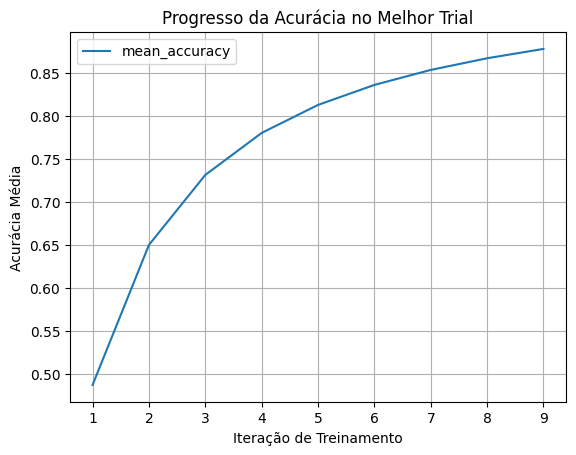

In [0]:
import matplotlib.pyplot as plt

# Plot accuracy over training iterations for the best trial
if best_result_df is not None and not best_result_df.empty:
    ax = best_result.metrics_dataframe.plot(
        x="training_iteration",
        y="mean_accuracy",
        grid=True,
        title="Progresso da Acurácia no Melhor Trial",
        xlabel="Iteração de Treinamento",
        ylabel="Acurácia Média",
    )
    plt.show()
else:
    print("DataFrame de métricas indisponível para plotagem.")